# **Prediksi Serangan Jantung menggunakan Machine Learning**

Notebook ini berisi model machine learning untuk memprediksi penyakit jantung menggunakan dataset Heart Attack Prediction.  
Model yang digunakan adalah  **Random Forest**



---
Dataset source: https://www.kaggle.com/datasets/imnikhilanand/heart-attack-prediction/data

## 1. Import Libraries

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import (
    train_test_split, StratifiedKFold,
    cross_val_score, cross_validate
)
from sklearn.ensemble import RandomForestClassifier
from sklearn.preprocessing import StandardScaler
from sklearn.impute import SimpleImputer
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.metrics import (
    accuracy_score, classification_report,
    confusion_matrix, ConfusionMatrixDisplay,
    precision_score, recall_score, f1_score,
    roc_auc_score, roc_curve,
    precision_recall_curve, average_precision_score, RocCurveDisplay
)
import shap


## 2. Load Data

In [2]:
from google.colab import drive
drive.mount('/content/drive')
file_path = "/content/drive/MyDrive/Celerates/Assignments/Asynchronus 4/data.csv"


df = pd.read_csv(file_path)
df.columns = df.columns.str.strip()

print(f"Shape dataset: {df.shape}")
print(f"Kolom: {df.columns.tolist()}")
df.head()

Mounted at /content/drive
Shape dataset: (294, 14)
Kolom: ['age', 'sex', 'cp', 'trestbps', 'chol', 'fbs', 'restecg', 'thalach', 'exang', 'oldpeak', 'slope', 'ca', 'thal', 'num']


,age,sex,cp,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,slope,ca,thal,num
0,28,1,2,130,132,0,2,185,0,0.0,?,?,?,0
1,29,1,2,120,243,0,0,160,0,0.0,?,?,?,0
2,29,1,2,140,?,0,0,170,0,0.0,?,?,?,0
3,30,0,1,170,237,0,1,170,0,0.0,?,?,6,0
4,31,0,2,100,219,0,1,150,0,0.0,?,?,?,0


In [3]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 294 entries, 0 to 293
Data columns (total 14 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   age       294 non-null    int64  
 1   sex       294 non-null    int64  
 2   cp        294 non-null    int64  
 3   trestbps  294 non-null    object 
 4   chol      294 non-null    object 
 5   fbs       294 non-null    object 
 6   restecg   294 non-null    object 
 7   thalach   294 non-null    object 
 8   exang     294 non-null    object 
 9   oldpeak   294 non-null    float64
 10  slope     294 non-null    object 
 11  ca        294 non-null    object 
 12  thal      294 non-null    object 
 13  num       294 non-null    int64  
dtypes: float64(1), int64(4), object(9)
memory usage: 32.3+ KB


In [4]:
df.describe().round(2)

,age,sex,cp,oldpeak,num
count,294.00,294.00,294.00,294.00,294.00
mean,47.83,0.72,2.98,0.59,0.36
std,7.81,0.45,0.97,0.91,0.48
min,28.00,0.00,1.00,0.00,0.00
25%,42.00,0.00,2.00,0.00,0.00
50%,49.00,1.00,3.00,0.00,0.00
75%,54.00,1.00,4.00,1.00,1.00
max,66.00,1.00,4.00,5.00,1.00


## 3. EDA (Exploratory Data Analysis)

EDA mencakup:
- Analisis missing values (pola & proporsi)
- Distribusi target (class balance)
- Distribusi fitur numerik vs target
- Distribusi fitur kategorikal vs target
- Deteksi outlier (IQR method)
- Analisis korelasi

### 3.1 Persiapan Data EDA

In [5]:
df_eda = df.copy()
df_eda.replace('?', np.nan, inplace=True)
for col in df_eda.columns:
    df_eda[col] = pd.to_numeric(df_eda[col], errors='coerce')

print("Shape setelah konversi:", df_eda.shape)
df_eda.head()

Shape setelah konversi: (294, 14)


,age,sex,cp,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,slope,ca,thal,num
0,28,1,2,130.0,132.0,0.0,2.0,185.0,0.0,0.0,NaN,NaN,NaN,0
1,29,1,2,120.0,243.0,0.0,0.0,160.0,0.0,0.0,NaN,NaN,NaN,0
2,29,1,2,140.0,NaN,0.0,0.0,170.0,0.0,0.0,NaN,NaN,NaN,0
3,30,0,1,170.0,237.0,0.0,1.0,170.0,0.0,0.0,NaN,NaN,6.0,0
4,31,0,2,100.0,219.0,0.0,1.0,150.0,0.0,0.0,NaN,NaN,NaN,0


### 3.2 Analisis Missing Values

In [6]:
missing     = df_eda.isnull().sum()
missing_pct = (missing / len(df_eda) * 100).round(2)
missing_info = pd.DataFrame({
    'Missing Count': missing,
    'Missing %': missing_pct
}).sort_values('Missing %', ascending=False)

print("Missing Values")
print(missing_info)

Missing Values
          Missing Count  Missing %
ca                  291      98.98
thal                266      90.48
slope               190      64.63
chol                 23       7.82
fbs                   8       2.72
trestbps              1       0.34
thalach               1       0.34
exang                 1       0.34
restecg               1       0.34
age                   0       0.00
cp                    0       0.00
sex                   0       0.00
oldpeak               0       0.00
num                   0       0.00


### 3.3 Distribusi Target (Class Balance)

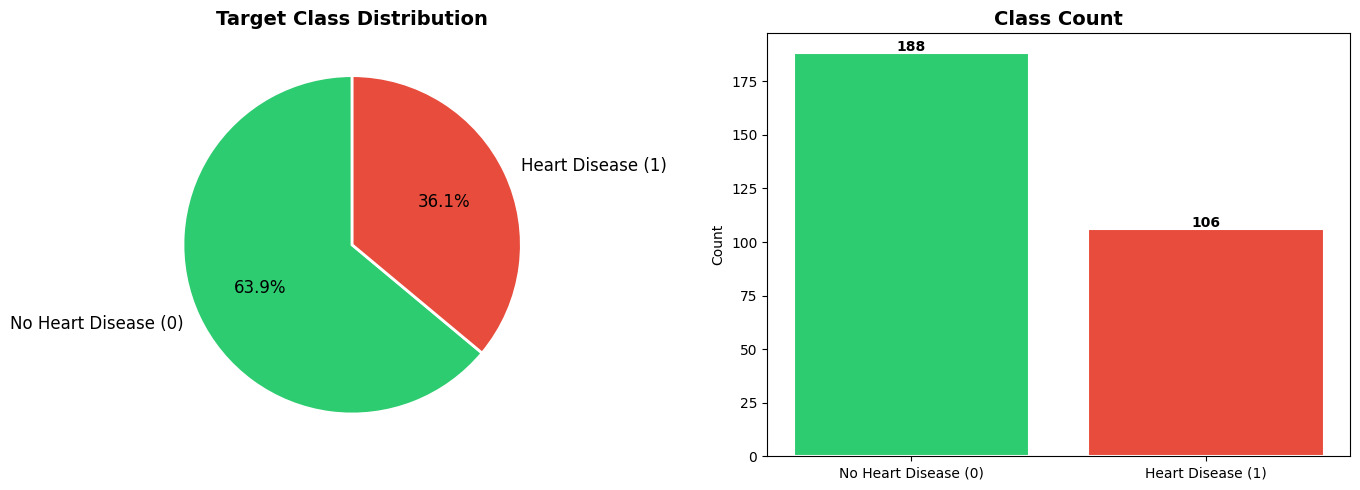

Rasio imbalance: 1.77:1  (No Disease : Heart Disease)
→ Perlu penanganan class imbalance: class_weight='balanced'


In [7]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

counts = df_eda['num'].value_counts()
labels = ['No Heart Disease (0)', 'Heart Disease (1)']
colors = ['#2ecc71', '#e74c3c']

axes[0].pie(counts.values, labels=labels, colors=colors, autopct='%1.1f%%',
            startangle=90,
            wedgeprops={'edgecolor': 'white', 'linewidth': 2},
            textprops={'fontsize': 12})
axes[0].set_title('Target Class Distribution', fontweight='bold', fontsize=14)

axes[1].bar(labels, counts.values, color=colors, edgecolor='white', linewidth=1.5)
axes[1].set_title('Class Count', fontweight='bold', fontsize=14)
axes[1].set_ylabel('Count')
for i, v in enumerate(counts.values):
    axes[1].text(i, v + 1, str(v), ha='center', fontweight='bold')

plt.tight_layout()
plt.show()

ratio = counts[0] / counts[1]
print(f"Rasio imbalance: {ratio:.2f}:1  (No Disease : Heart Disease)")
print("→ Perlu penanganan class imbalance: class_weight='balanced'")

### 3.4 Distribusi Fitur Numerik

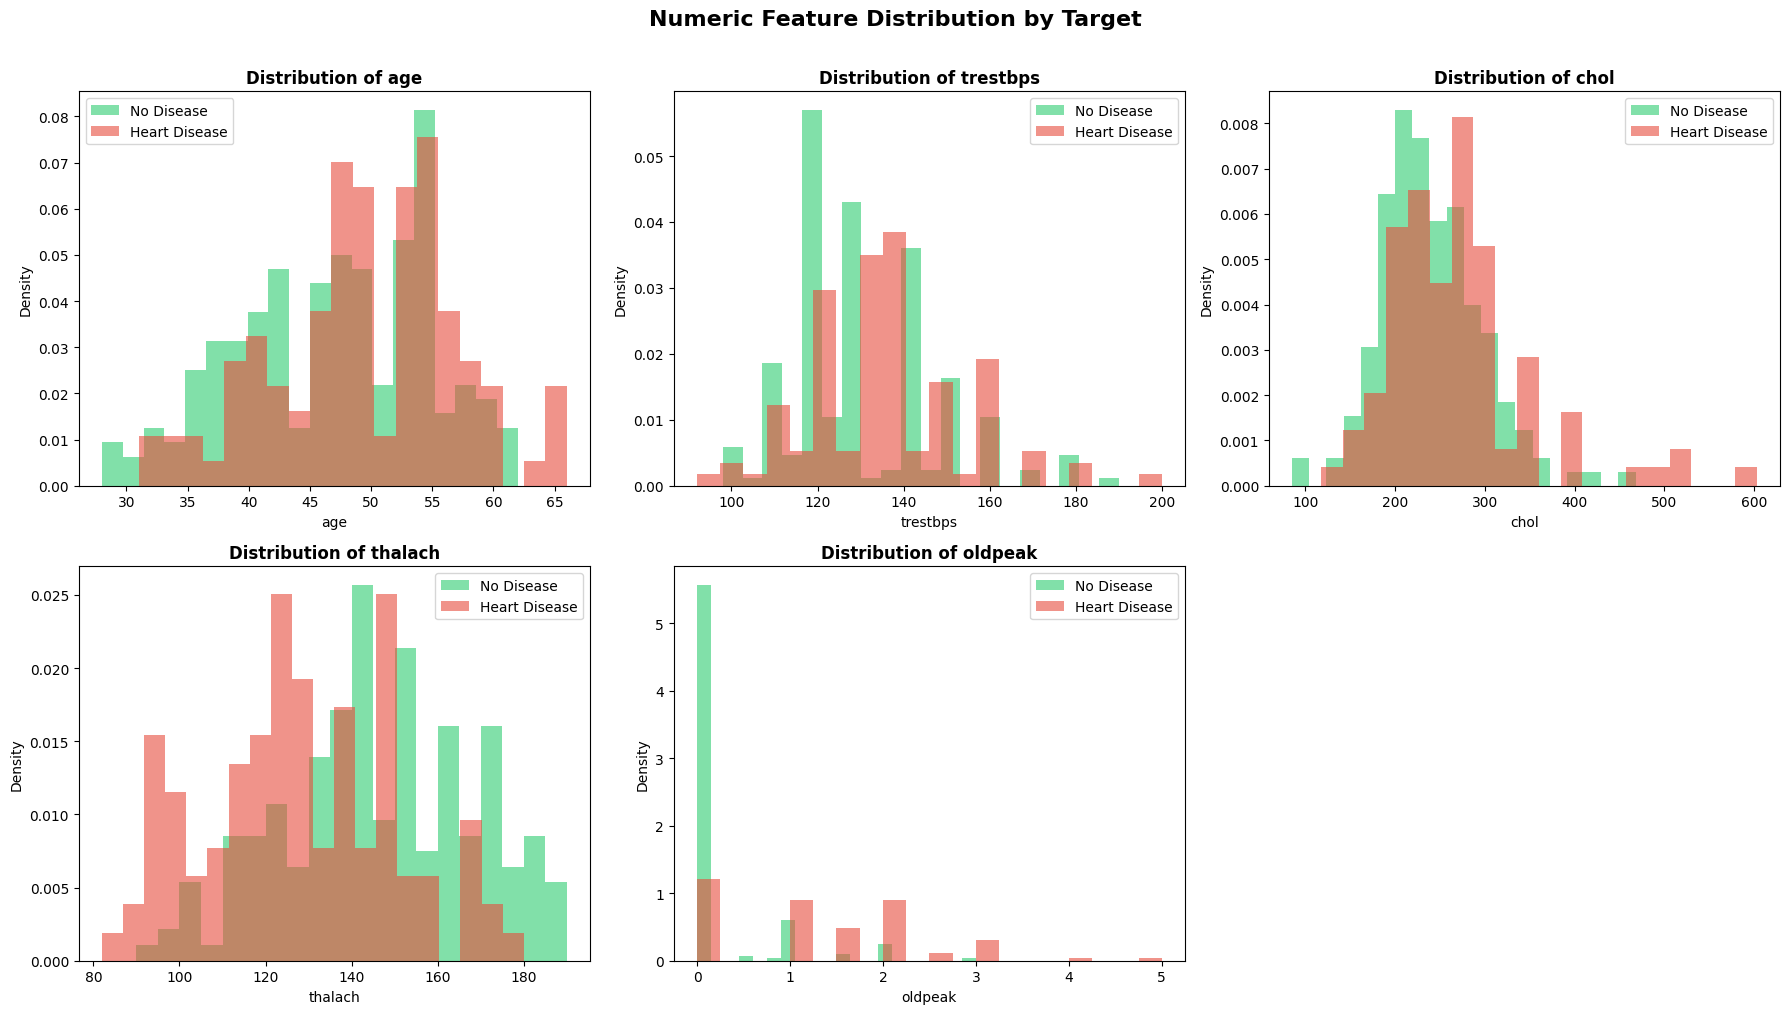

In [8]:
numeric_features = ['age', 'trestbps', 'chol', 'thalach', 'oldpeak']

fig, axes = plt.subplots(2, 3, figsize=(18, 10))
axes = axes.flatten()

for i, feat in enumerate(numeric_features):
    no_dis = df_eda[df_eda['num'] == 0][feat].dropna()
    dis    = df_eda[df_eda['num'] == 1][feat].dropna()
    axes[i].hist(no_dis, bins=20, alpha=0.6, color='#2ecc71',
                 label='No Disease', density=True)
    axes[i].hist(dis,    bins=20, alpha=0.6, color='#e74c3c',
                 label='Heart Disease', density=True)
    axes[i].set_title(f'Distribution of {feat}', fontweight='bold')
    axes[i].set_xlabel(feat)
    axes[i].set_ylabel('Density')
    axes[i].legend()

axes[-1].axis('off')
plt.suptitle('Numeric Feature Distribution by Target',
             fontsize=16, fontweight='bold', y=1.01)
plt.tight_layout()
plt.show()

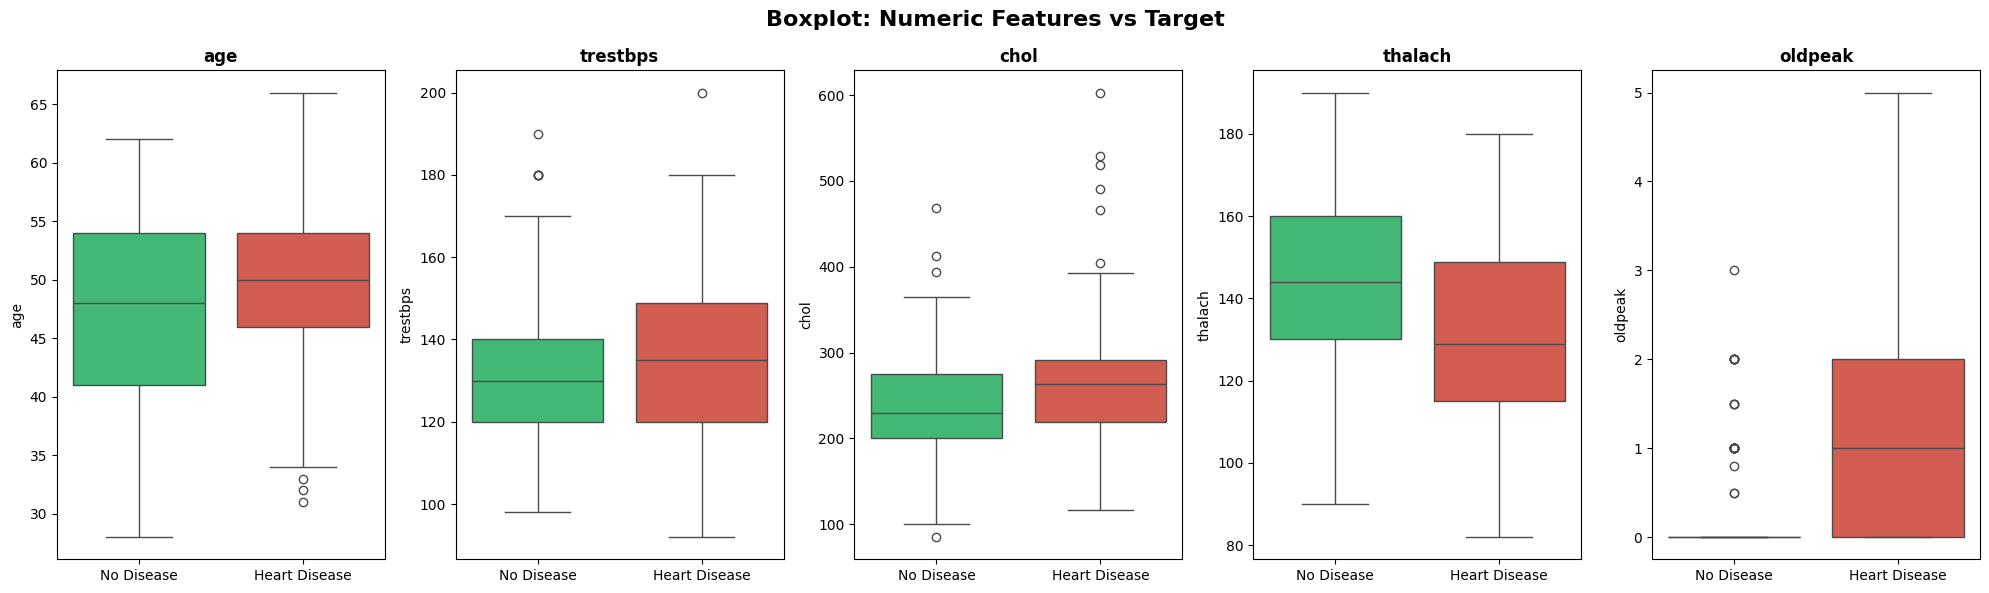

In [9]:
# Boxplot per fitur numerik vs target
df_plot = df_eda.copy()
df_plot['disease_status'] = df_plot['num'].map({0: 'No Disease', 1: 'Heart Disease'})

fig, axes = plt.subplots(1, len(numeric_features), figsize=(20, 6))
palette = {'No Disease': '#2ecc71', 'Heart Disease': '#e74c3c'}

for i, feat in enumerate(numeric_features):
    sns.boxplot(data=df_plot, x='disease_status', y=feat,
                hue='disease_status', palette=palette, ax=axes[i], legend=False)
    axes[i].set_title(f'{feat}', fontweight='bold')
    axes[i].set_xlabel('')

plt.suptitle('Boxplot: Numeric Features vs Target',
             fontsize=16, fontweight='bold')
plt.tight_layout()
plt.show()

### 3.5 Distribusi Fitur Kategori

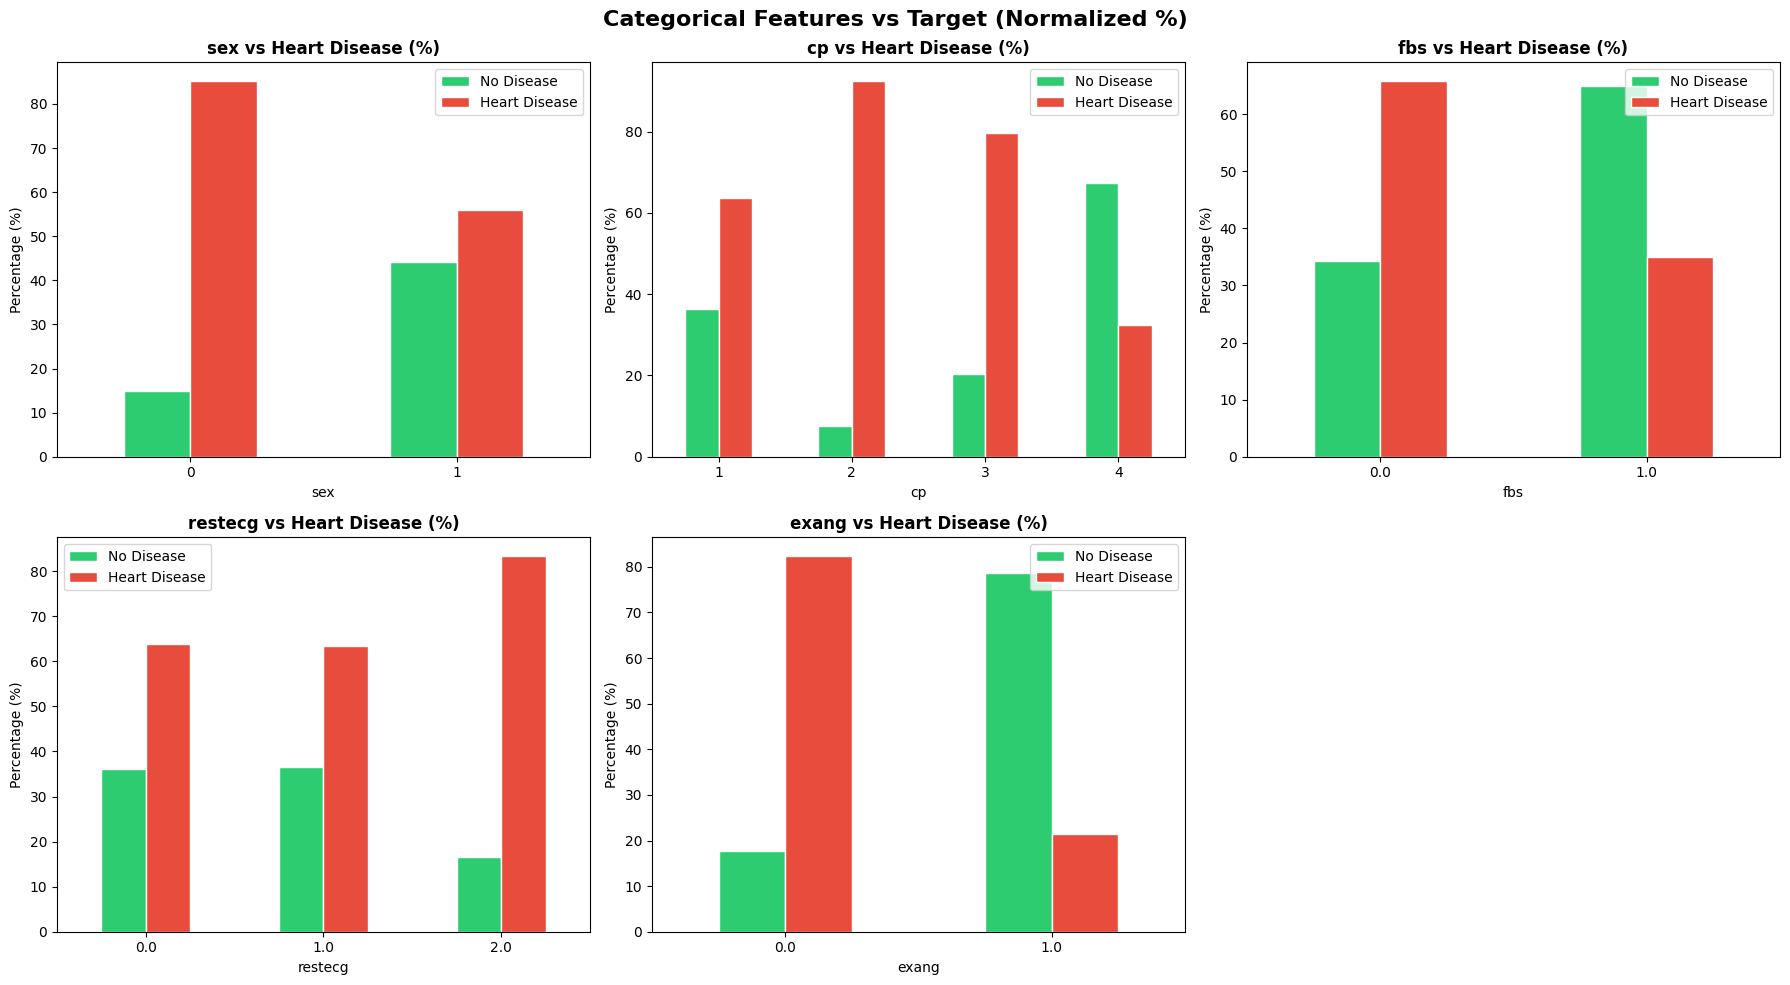

In [10]:
cat_features = ['sex', 'cp', 'fbs', 'restecg', 'exang']

fig, axes = plt.subplots(2, 3, figsize=(18, 10))
axes = axes.flatten()

for i, feat in enumerate(cat_features):
    ct = pd.crosstab(df_plot[feat], df_plot['disease_status'],
                     normalize='index') * 100
    ct.plot(kind='bar', ax=axes[i],
            color=['#2ecc71', '#e74c3c'], edgecolor='white')
    axes[i].set_title(f'{feat} vs Heart Disease (%)', fontweight='bold')
    axes[i].set_xlabel(feat)
    axes[i].set_ylabel('Percentage (%)')
    axes[i].legend(['No Disease', 'Heart Disease'])
    axes[i].tick_params(axis='x', rotation=0)

axes[-1].axis('off')
plt.suptitle('Categorical Features vs Target (Normalized %)',
             fontsize=16, fontweight='bold')
plt.tight_layout()
plt.show()

### 3.6 Deteksi Outlier

=== Outlier Detection (IQR Method) ===
          Outlier Count  Outlier %  Lower Bound  Upper Bound
age                 0.0       0.00        24.00        72.00
trestbps            8.0       2.72        90.00       170.00
chol               11.0       3.74        98.75       392.75
thalach             0.0       0.00        72.50       204.50
oldpeak            11.0       3.74        -1.50         2.50


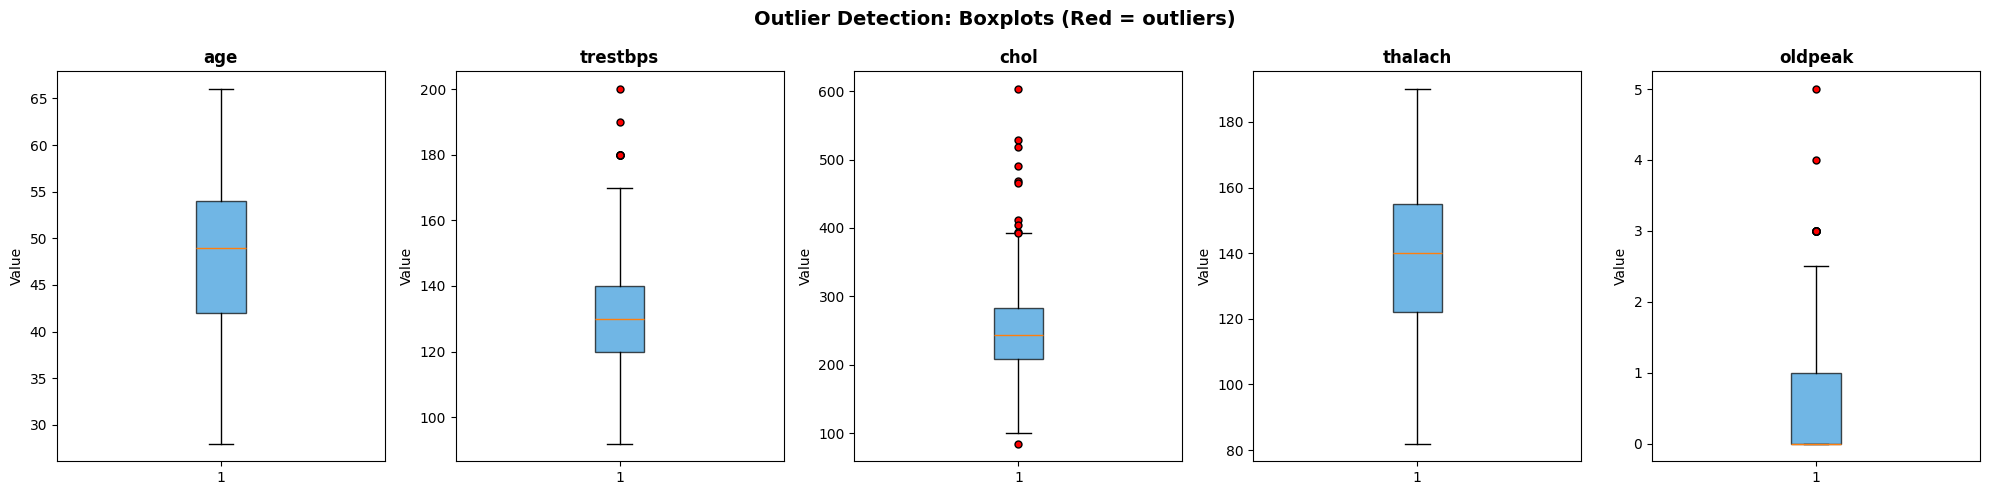

In [11]:
def detect_outliers_iqr(df, columns):
    info = {}
    for col in columns:
        Q1  = df[col].quantile(0.25)
        Q3  = df[col].quantile(0.75)
        IQR = Q3 - Q1
        lo  = Q1 - 1.5 * IQR
        hi  = Q3 + 1.5 * IQR
        out = df[(df[col] < lo) | (df[col] > hi)][col]
        info[col] = {
            'Outlier Count': len(out),
            'Outlier %': round(len(out) / len(df) * 100, 2),
            'Lower Bound': round(lo, 2),
            'Upper Bound': round(hi, 2)
        }
    return pd.DataFrame(info).T

outlier_df = detect_outliers_iqr(df_eda, numeric_features)
print("=== Outlier Detection (IQR Method) ===")
print(outlier_df)

fig, axes = plt.subplots(1, len(numeric_features), figsize=(20, 5))
for i, feat in enumerate(numeric_features):
    axes[i].boxplot(
        df_eda[feat].dropna(), patch_artist=True,
        boxprops=dict(facecolor='#3498db', alpha=0.7),
        flierprops=dict(marker='o', markerfacecolor='red', markersize=5)
    )
    axes[i].set_title(feat, fontweight='bold')
    axes[i].set_ylabel('Value')

plt.suptitle('Outlier Detection: Boxplots (Red = outliers)',
             fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

### 3.7 Analisis Korelasi

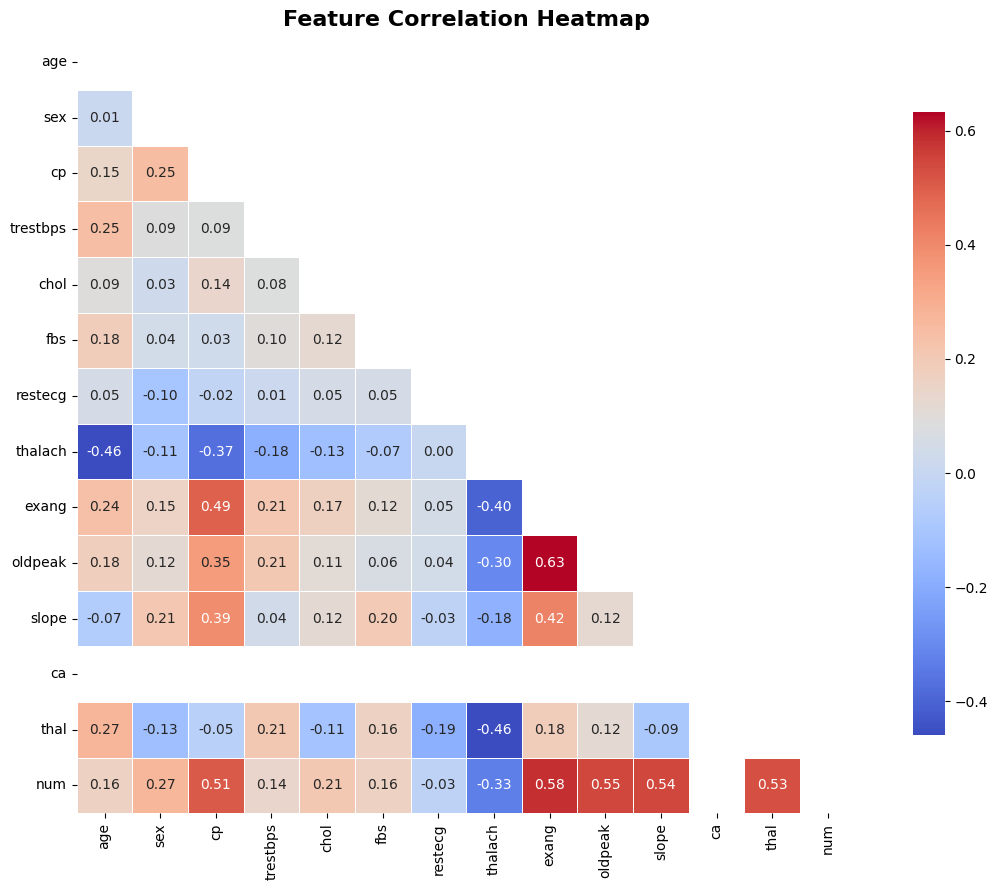

In [12]:
plt.figure(figsize=(12, 9))
corr = df_eda.corr()
mask = np.triu(np.ones_like(corr, dtype=bool))
sns.heatmap(corr, annot=True, fmt='.2f', cmap='coolwarm',
            linewidths=0.5, mask=mask, square=True,
            cbar_kws={'shrink': .8})
plt.title('Feature Correlation Heatmap', fontsize=16, fontweight='bold')
plt.tight_layout()
plt.show()


## 4. Preprocessing


In [13]:
df_clean = df.copy()
df_clean.replace('?', np.nan, inplace=True)
for col in df_clean.columns:
    df_clean[col] = pd.to_numeric(df_clean[col], errors='coerce')

drop_column = ['ca', 'thal', 'slope']
df_clean.drop(columns=drop_column, inplace=True)
print(f"Dropped: {drop_column}")

X = df_clean.drop('num', axis=1)
y = df_clean['num']

print(f"\nFeatures: {X.columns.tolist()}")
print(f"Shape X : {X.shape}")
print(f"Shape y : {y.shape}")
print(f"\nMissing per feature:")
print(X.isnull().sum())

Dropped: ['ca', 'thal', 'slope']

Features: ['age', 'sex', 'cp', 'trestbps', 'chol', 'fbs', 'restecg', 'thalach', 'exang', 'oldpeak']
Shape X : (294, 10)
Shape y : (294,)

Missing per feature:
age          0
sex          0
cp           0
trestbps     1
chol        23
fbs          8
restecg      1
thalach      1
exang        1
oldpeak      0
dtype: int64


In [14]:
# Feature Engineering
X_eng = X.copy()

X_eng['age_group'] = pd.cut(X_eng['age'],
    bins=[0, 40, 55, 70, 100], labels=[0, 1, 2, 3]).astype(float)
X_eng['high_chol'] = (X_eng['chol']    > 240).astype(int)
X_eng['high_bp']   = (X_eng['trestbps'] > 140).astype(int)
X_eng['hr_reserve'] = 220 - X_eng['age'] - X_eng['thalach']

print("Engineered features added:")
print("  age_group  — Age binned (0-3)")
print("  high_chol  — Cholesterol > 240 mg/dL")
print("  high_bp    — Resting BP > 140 mmHg")
print("  hr_reserve — Estimated heart rate reserve")
print(f"\nTotal features: {X_eng.shape[1]}")
print(f"Features: {X_eng.columns.tolist()}")

# Split data
X_train, X_test, y_train, y_test = train_test_split(
    X_eng, y, test_size=0.20, random_state=42, stratify=y
)

print(f"\nTraining set : {X_train.shape[0]} samples")
print(f"Test set     : {X_test.shape[0]} samples")
print(f"\nTrain class distribution: {y_train.value_counts().to_dict()}")
print(f"Test  class distribution: {y_test.value_counts().to_dict()}")


Engineered features added:
  age_group  — Age binned (0-3)
  high_chol  — Cholesterol > 240 mg/dL
  high_bp    — Resting BP > 140 mmHg
  hr_reserve — Estimated heart rate reserve

Total features: 14
Features: ['age', 'sex', 'cp', 'trestbps', 'chol', 'fbs', 'restecg', 'thalach', 'exang', 'oldpeak', 'age_group', 'high_chol', 'high_bp', 'hr_reserve']

Training set : 235 samples
Test set     : 59 samples

Train class distribution: {0: 150, 1: 85}
Test  class distribution: {0: 38, 1: 21}


In [15]:
X_train, X_test, y_train, y_test = train_test_split(
    X_eng, y, test_size=0.20, random_state=42, stratify=y
)

print(f"Training set : {X_train.shape[0]} samples")
print(f"Test set     : {X_test.shape[0]} samples")
print(f"\nTrain class distribution: {y_train.value_counts().to_dict()}")
print(f"Test  class distribution: {y_test.value_counts().to_dict()}")

Training set : 235 samples
Test set     : 59 samples

Train class distribution: {0: 150, 1: 85}
Test  class distribution: {0: 38, 1: 21}


In [16]:
continuous_cols  = ['age', 'trestbps', 'chol', 'thalach', 'oldpeak']
categorical_cols = ['sex', 'cp', 'fbs', 'restecg', 'exang']
engineered_cols  = ['age_group', 'high_chol', 'high_bp', 'hr_reserve']

cont_idx = [X_eng.columns.get_loc(c) for c in continuous_cols + engineered_cols]
cat_idx  = [X_eng.columns.get_loc(c) for c in categorical_cols]

feature_names_out = continuous_cols + engineered_cols + categorical_cols

print("Continuous + Engineered idx:", cont_idx)
print("Categorical idx:", cat_idx)


Continuous + Engineered idx: [0, 3, 4, 7, 9, 10, 11, 12, 13]
Categorical idx: [1, 2, 5, 6, 8]


## 5. Model

Classification Report

                  precision    recall  f1-score   support

No Heart Disease       0.83      0.89      0.86        38
   Heart Disease       0.78      0.67      0.72        21

        accuracy                           0.81        59
       macro avg       0.80      0.78      0.79        59
    weighted avg       0.81      0.81      0.81        59



<Figure size 1000x600 with 0 Axes>

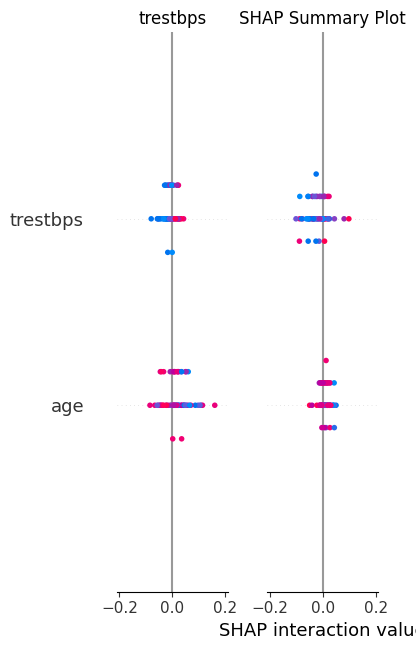

In [17]:
numeric_transformer = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='mean')),
    ('scaler', StandardScaler())
])

categorical_transformer = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='most_frequent'))
])

preprocessor = ColumnTransformer(
    transformers=[
        ('num', numeric_transformer, continuous_cols + engineered_cols),
        ('cat', categorical_transformer, categorical_cols)
    ],
    remainder='passthrough'
)

rf_pipeline = Pipeline(steps=[
    ('preprocessor', preprocessor),
    ('classifier', RandomForestClassifier(random_state=42, class_weight='balanced'))
])

rf_pipeline.fit(X_train, y_train)

y_pred = rf_pipeline.predict(X_test)
print("Classification Report\n")
print(classification_report(y_test, y_pred, target_names=['No Heart Disease', 'Heart Disease']))

rf_model_fitted = rf_pipeline.named_steps['classifier']
preprocessor_fitted = rf_pipeline.named_steps['preprocessor']

X_test_transformed = preprocessor_fitted.transform(X_test)

explainer = shap.TreeExplainer(rf_model_fitted)
shap_values = explainer.shap_values(X_test_transformed)

if isinstance(shap_values, list):
    actual_shap_values = shap_values[1]
else:
    actual_shap_values = shap_values

plt.figure(figsize=(10, 6))
shap.summary_plot(actual_shap_values, X_test_transformed, feature_names=feature_names_out, show=False)
plt.title('SHAP Summary Plot')
plt.tight_layout()
plt.show()

<Figure size 700x500 with 0 Axes>

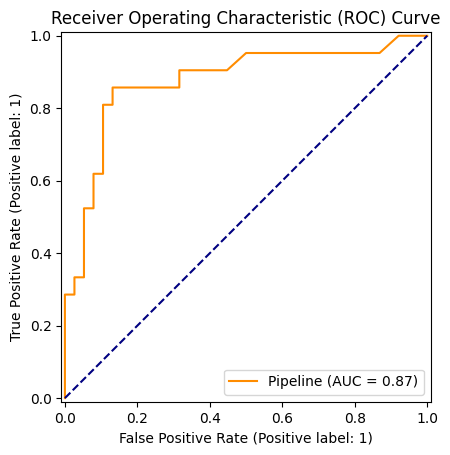

In [18]:
plt.figure(figsize=(7, 5))
RocCurveDisplay.from_estimator(rf_pipeline, X_test, y_test, color='darkorange')
plt.plot([0, 1], [0, 1], color='navy', linestyle='--')
plt.title('Receiver Operating Characteristic (ROC) Curve')
plt.show()

<Figure size 600x400 with 0 Axes>

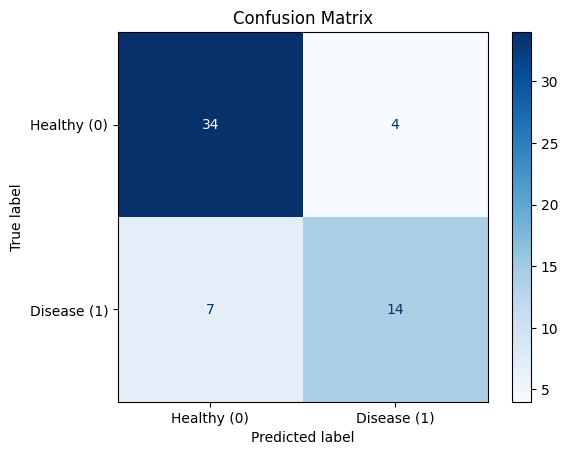

In [19]:
plt.figure(figsize=(6, 4))
ConfusionMatrixDisplay.from_estimator(rf_pipeline, X_test, y_test,
                                      display_labels=['Healthy (0)', 'Disease (1)'],
                                      cmap='Blues')
plt.title('Confusion Matrix')
plt.grid(False)
plt.show()

True Negative (TN) = 34 → Healthy diprediksi Healthy
False Positive (FP) = 4 → Healthy tapi diprediksi Disease
False Negative (FN) = 7 → Disease tapi diprediksi Healthy
True Positive (TP) = 14 → Disease diprediksi Disease

Total data = 59

